In [2]:
import os

# Groq (model provider)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

# Search API keys
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"] = os.getenv("SERPER_API_KEY")

print("Keys set!")


TypeError: str expected, not NoneType

In [37]:
from langchain.chat_models import init_chat_model

# Use Groq LLM
model = init_chat_model(
    model="groq:llama-3.3-70b-versatile",  # Large model for tool calling
    temperature=0.3
)

print("LLM initialized:", model)


LLM initialized: profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x00000169AE36D690> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000169AE425090> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********')


In [38]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily search tool ready")


Tavily search tool ready


In [39]:
from langchain_community.utilities import GoogleSerperAPIWrapper

google_search = GoogleSerperAPIWrapper()

print("Google Serper wrapper ready")


Google Serper wrapper ready


In [62]:
result = google_search.run("best places to visit in Kasol travel guide")
print("Google Serper raw:", result)


Google Serper raw: What are the places to see around Kasol? · Manikaran – Amongst the many villages, Kasol to Manikaran would make for a good day's visit. · Chalal – ... Top Attractions in Kasol ; 1. Sar Pass Trek · 4.9. (14). Hiking Trails ; 2. Parvati Valley. Mountains ; 4. Ayur Spa · 4.8. (5). Spas ; 5. Psychedelic Painting Shop. Stay near Parvati river - lots of stays - some campsites as well ; If you like to trek - Kheerganga is good, crowded yes but beautiful, if you do ... The ultimate guide to places to visit near Kasol, doing treks near Kasol, Kheerganga, Parvati Valley, Manikaran. 1. Nature Park. Just beside the Parvati Valley is one of the best places to visit in Kasol. Yes, we are talking about the nature park that ... Discover the best places to visit in Kasol—rivers, treks, villages, cafés & culture. Your complete travel guide to Mini Israel of India with tips ... Tourist Places in Kasol. Seek Blessings at Gurudwara Shri Manikaran Sahib, Camp in the Parvati Valley, Manika

In [ ]:
from langchain_core.tools import Tool 


def tavily_search_tool(query: str) -> str:
    """
    Search the web using Tavily for travel info, tips, attractions, etc.
    """
    # Call the existing TavilySearch tool underneath
    return tavily_search.invoke({"query": query})


def google_serper_search_tool(query: str) -> str:
    """
    Search the web using Google Serper for up-to-date travel info.
    """
    return google_search.run(query)



In [59]:
# testing the funcitonality 

tavily_search_tool("Plan a trip to india")

{'query': 'Plan a trip to india',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.foratravel.com/the-journal/planning-a-trip-to-india',
   'title': "A Beginner's Guide to Planning a Trip to India - Fora Travel",
   'content': 'From the moment I arrived, I was swept up in the sensory overload — vibrant colors, soul-stirring flavors, the hum of bustling people and a culture so rich it leaves you mesmerized. We even met the mastermind behind the hotel’s restoration and climbed to the rooftop for panoramic views of Old Delhi — an incredible moment of calm above the chaos. ## Day 2: Delhi in full color. We kicked off the day with a sunrise stroll through the Lodhi Art District — a living, breathing gallery where every wall tells a story. We dove headfirst into an Indian wedding experience, where we got to play bride for a day\xa0— think Bollywood dance lessons, sari embroidery and coffee cup astrology (yes, that’s a thing!). The journey took u

In [ ]:
# testing the funcitonality 

google_serper_search_tool("Plan a 5 trip to india")

"This five-day tour includes the best of India's Golden Triangle (Delhi, Agra, and Jaipur), including the Taj Mahal, the Red Fort, Jaipur's City Palace, and lots ... We are planning for a 5-6 days trip but kinda not sure on which part of India we should explore. Mostly want to have a quiet time with small treks and good ... We spent 5 Days in India's Tourist Triangle (Delhi, Agra, and Jaipur)! In this video we share our experiences in India and give tips to plan ... Traveling 5 days in India? Explore India in 5 days with these unique India 5-day itinerary recommendations. Visit Goa, Jaipur, Delhi and Ranthambore! Hi all. We are travelling to India for approximately 5weeks including flights there and back. The following is our itinerary:. India Golden Triangle Tour ... Many first-time visitors do a Golden Triangle tour, which visits the three cities of Delhi, Jaipur and Agra, to see the Taj Mahal. If you have 5–6 days you can plan a trip to Kerala or Rajasthan or some of the North East 

Travel planner agent ready!


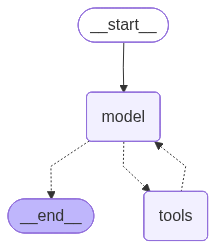

In [61]:
from langchain.agents import create_agent

system_prompt = """
You are a travel planner assistant. User asks travel queries like
'plan my trip to X', 'what to do in Y hotel', etc.
Always use the available web search tools (TavilySearch, GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answers.
"""

agent = create_agent(
    model=model,
    tools=[tavily_search_tool , google_serper_search_tool],
    system_prompt=system_prompt.strip()
)

print("Travel planner agent ready!")
agent

In [53]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Give me a 3 day plan for Kasol travel with places to see."}
    ]
})

print("Agent answer:\n")
print(response)


Agent answer:

{'messages': [HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='7148beee-353f-4da1-8a27-45d95e636231'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9qmkvzzkd', 'function': {'arguments': '{"query":"Kasol travel plan 3 days"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': '8096cf56x', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 391, 'total_tokens': 437, 'completion_time': 0.090727142, 'completion_tokens_details': None, 'prompt_time': 0.03301617, 'prompt_tokens_details': None, 'queue_time': 0.06107133, 'total_time': 0.123743312}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'g

In [ ]:
response["messages"]

[HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='7148beee-353f-4da1-8a27-45d95e636231'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '9qmkvzzkd', 'function': {'arguments': '{"query":"Kasol travel plan 3 days"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': '8096cf56x', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 46, 'prompt_tokens': 391, 'total_tokens': 437, 'completion_time': 0.090727142, 'completion_tokens_details': None, 'prompt_time': 0.03301617, 'prompt_tokens_details': None, 'queue_time': 0.06107133, 'total_time': 0.123743312}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_c06d5113ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019bc109

less safe 

In [64]:
final_answer = response["messages"][-1].content
print(final_answer)


Here's a 3-day plan for your trip to Kasol:

Day 1: 
- Arrive in Kasol and check into your hotel or campsite.
- Visit the Kasol Market and shop for souvenirs.
- Take a walk by the Parvati River and enjoy the scenic views.
- In the evening, enjoy a bonfire with music at your campsite.

Day 2: 
- Trek to Chalal Village and explore the village.
- Visit the Gurudwara Shri Manikaran Sahib and take a dip in the hot springs.
- In the evening, enjoy a peaceful walk in the Nature Park.

Day 3: 
- Trek to Kheerganga and enjoy the scenic views from the top.
- Visit the Tosh Village and explore the village.
- In the evening, return to Kasol and enjoy a relaxing walk by the Parvati River.

This plan includes a mix of trekking, sightseeing, and relaxation, and is a good way to experience the beauty of Kasol. However, you can customize the plan according to your preferences and interests.


more safe

In [63]:
from langchain_core.messages import AIMessage

def get_final_answer(agent_response):
    for message in reversed(agent_response["messages"]):
        if isinstance(message, AIMessage) and message.content:
            return message.content

final_answer = get_final_answer(response)
print(final_answer)


Here's a 3-day plan for your trip to Kasol:

Day 1: 
- Arrive in Kasol and check into your hotel or campsite.
- Visit the Kasol Market and shop for souvenirs.
- Take a walk by the Parvati River and enjoy the scenic views.
- In the evening, enjoy a bonfire with music at your campsite.

Day 2: 
- Trek to Chalal Village and explore the village.
- Visit the Gurudwara Shri Manikaran Sahib and take a dip in the hot springs.
- In the evening, enjoy a peaceful walk in the Nature Park.

Day 3: 
- Trek to Kheerganga and enjoy the scenic views from the top.
- Visit the Tosh Village and explore the village.
- In the evening, return to Kasol and enjoy a relaxing walk by the Parvati River.

This plan includes a mix of trekking, sightseeing, and relaxation, and is a good way to experience the beauty of Kasol. However, you can customize the plan according to your preferences and interests.
